# Biplane over Densities - Evaluation

In [1]:
try:
    import mat73
except ImportError:
    pass

from pathlib import Path
from typing import Sequence

import math
import matplotlib.pyplot as plt
# plt.style.use("/mnt/t1ries/users/Lucas/Manuscripts/style/thesis.mplstyle")

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

In [2]:
path = "../../../"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

In [3]:
import decode
import decode.neuralfitter.inference.functional as infer_func
print(decode.__file__)
log = decode.generic.logging.get_logger(__name__)

%config InlineBackend.figure_format='retina'

/data1/shah/miniconda3/envs/decode_uipsf/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/shahao/projects/DECODE-Plex/notebook/biplane/simulation/../../../decode/__init__.py


In [ ]:
# figure out
path_out = "../../../results/density/Fig1c-biplane"
path_out = Path(path_out)

In [ ]:
# some paths and hardware settings
path_scen_base = "../../../data/density/Fig1c-biplane/n_frames-1000_n_steps-16_seed-42"
path_scen_base = Path(path_scen_base)

path_scen = path_scen_base / "scenarios.pq"
scen = pd.read_parquet(path_scen)

frames = path_scen_base / "frames.pt"
frames = torch.load(frames)

path_gt = path_scen_base / "gt.pt"
gt = torch.load(path_gt)

scen["em"] = gt["em"]
scen["em_ch"] = gt["em_ch"]
scen

n_emitter   density  n_frames  phot_loc  phot_scale  \
snr    index                                                          
medium 0        11.624977  0.030000      1000    5000.0      1250.0   
       1        15.802486  0.040781      1000    5000.0      1250.0   
       2        21.481211  0.055435      1000    5000.0      1250.0   
       3        29.200621  0.075357      1000    5000.0      1250.0   
       4        39.694050  0.102436      1000    5000.0      1250.0   
       5        53.958359  0.139248      1000    5000.0      1250.0   
       6        73.348648  0.189287      1000    5000.0      1250.0   
       7        99.706947  0.257309      1000    5000.0      1250.0   
       8       135.537292  0.349774       737    5000.0      1250.0   
       9       184.243484  0.475468       542    5000.0      1250.0   
       10      250.452545  0.646330       399    5000.0      1250.0   
       11      340.454254  0.878593       293    5000.0      1250.0   
       12      462.798676  1.194322       216    5000.0      1250.0   
       13      629.108337  1.623509       158    5000.0      1250.0   
       14      855.182434  2.206927       116    5000.0      1250.0   
       15     1162.497681  3.000000        86    5000.0      1250.0   

                        bg      choric  lifetime  phot_min  \
snr    index                                                 
medium 0      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       1      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       2      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       3      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       4      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       5      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       6      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       7      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       8      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       9      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       10     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       11     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       12     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       13     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       14     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       15     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   

                                                             em  \
snr    index                                                      
medium 0      EmitterSet
::num emitters: 11076
::xy unit: px...   
       1      EmitterSet
::num emitters: 15306
::xy unit: px...   
       2      EmitterSet
::num emitters: 20682
::xy unit: px...   
       3      EmitterSet
::num emitters: 28210
::xy unit: px...   
       4      EmitterSet
::num emitters: 38956
::xy unit: px...   
       5      EmitterSet
::num emitters: 52219
::xy unit: px...   
       6      EmitterSet
::num emitters: 71697
::xy unit: px...   
       7      EmitterSet
::num emitters: 96771
::xy unit: px...   
       8      EmitterSet
::num emitters: 95804
::xy unit: px...   
       9      EmitterSet
::num emitters: 96407
::xy unit: px...   
       10     EmitterSet
::num emitters: 97605
::xy unit: px...   
       11     EmitterSet
::num emitters: 96536
::xy unit: px...   
       12     EmitterSet
::num emitters: 96681
::xy unit: px...   
       13     EmitterSet
::num emitters: 96808
::xy unit: px...   
       14     EmitterSet
::num emitters: 96355
::xy unit: px...   
       15     EmitterSet
::num emitters: 97502
::xy unit: px...   

                                                          em_ch  
snr    index                                                     
medium 0      EmitterSet
::num emitters: 11076
::xy unit: px...  
       1      EmitterSet
::num emitters: 15306
::xy unit: px...  
       2      EmitterSet
::num emitters: 20682
::xy unit: px...  
       3      EmitterSet
::num emitters: 28210
::xy unit: px...  
       4      Emi

In [6]:
path_decode = path_scen_base / "decode_fit.pt"

decode_fit = torch.load(path_decode)

scen_decode = pd.DataFrame(index=scen.index)
scen_decode["em_out"] = None

for i, r in scen_decode.iterrows():
    scen_decode.at[i, "em_out"] = decode_fit[i[-1]]

scen_decode["algorithm"] = "DECODE"
scen_decode.set_index("algorithm", append=True, inplace=True)
scen_decode

em_out
snr    index algorithm                                                   
medium 0     DECODE     EmitterSet
::num emitters: 12732
::xy unit: px...
       1     DECODE     EmitterSet
::num emitters: 16997
::xy unit: px...
       2     DECODE     EmitterSet
::num emitters: 22688
::xy unit: px...
       3     DECODE     EmitterSet
::num emitters: 30474
::xy unit: px...
       4     DECODE     EmitterSet
::num emitters: 41632
::xy unit: px...
       5     DECODE     EmitterSet
::num emitters: 55210
::xy unit: px...
       6     DECODE     EmitterSet
::num emitters: 75461
::xy unit: px...
       7     DECODE     EmitterSet
::num emitters: 101235
::xy unit: p...
       8     DECODE     EmitterSet
::num emitters: 99906
::xy unit: px...
       9     DECODE     EmitterSet
::num emitters: 100059
::xy unit: p...
       10    DECODE     EmitterSet
::num emitters: 100305
::xy unit: p...
       11    DECODE     EmitterSet
::num emitters: 98214
::xy unit: px...
       12    DECODE     EmitterSet
::num emitters: 96869
::xy unit: px...
       13    DECODE     EmitterSet
::num emitters: 94783
::xy unit: px...
       14    DECODE     EmitterSet
::num emitters: 90674
::xy unit: px...
       15    DECODE     EmitterSet
::num emitters: 86260
::xy unit: px...

In [7]:
# load SMAP
path_bulk = path_scen_base / "scen_bulk.pq"

px_size = (100., 100.)

scen_bulk = pd.read_parquet(path_bulk)
scen_bulk["algorithm"] = "SMAP"
scen_bulk.set_index("algorithm", append=True, inplace=True)
scen_bulk["em_out"] = None
scen_bulk["em_tot"] = None
scen_bulk["path_em"] = None
# scen_bulk.loc["high", "path_em"] = path_scen_base / "frames_snr-high_offset-100_ome_sml.mat"
scen_bulk.loc["medium", "path_em"] = path_scen_base / "frames_snr-medium_offset-100_ome-flip_sml.mat"
# scen_bulk.loc["low", "path_em"] = path_scen_base / "frames_snr-low_offset-100_ome_sml.mat"


for i, r in scen_bulk.iterrows():
    if r["path_em"] is None:
        continue

    data, *_ = decode.io.emitter.load_smap(r["path_em"], return_raw=True)
    raw = data.pop("raw")

    em = decode.EmitterSet(
        **data,
        prob=raw["LLrel"].squeeze(),
        xy_unit="nm",
        px_size=px_size,
    )
    em.xyz_nm = em.xyz_nm[:, [1, 0, 2]]
    em.xyz_nm -= torch.tensor([85.4058, 100.9165,   7.9485])
    # em.xyz_nm += torch.tensor([-85.3, -103.5, 0.])

    scen_bulk.at[i, "em_tot"] = em
    em = em.iframe[r["ix_low"]:r["ix_high"]]
    em.frame_ix -= r["ix_low"]
    scen_bulk.at[i, "em_out"] = em


scen_smap = scen_bulk[["em_out"]]
scen_smap

em_out
snr    index algorithm                                                   
medium 0     SMAP       EmitterSet
::num emitters: 11013
::xy unit: nm...
       1     SMAP       EmitterSet
::num emitters: 14712
::xy unit: nm...
       2     SMAP       EmitterSet
::num emitters: 19146
::xy unit: nm...
       3     SMAP       EmitterSet
::num emitters: 25149
::xy unit: nm...
       4     SMAP       EmitterSet
::num emitters: 33461
::xy unit: nm...
       5     SMAP       EmitterSet
::num emitters: 42803
::xy unit: nm...
       6     SMAP       EmitterSet
::num emitters: 55813
::xy unit: nm...
       7     SMAP       EmitterSet
::num emitters: 70306
::xy unit: nm...
       8     SMAP       EmitterSet
::num emitters: 63671
::xy unit: nm...
       9     SMAP       EmitterSet
::num emitters: 57232
::xy unit: nm...
       10    SMAP       EmitterSet
::num emitters: 48990
::xy unit: nm...
       11    SMAP       EmitterSet
::num emitters: 39404
::xy unit: nm...
       12    SMAP       EmitterSet
::num emitters: 29468
::xy unit: nm...
       13    SMAP       EmitterSet
::num emitters: 19184
::xy unit: nm...
       14    SMAP       EmitterSet
::num emitters: 10947
::xy unit: nm...
       15    SMAP       EmitterSet
::num emitters: 5138
::xy unit: nm
...

In [8]:
scen_pred = pd.concat([scen_decode, scen_smap], axis=0)
scen_pred["em"] = scen["em"]

scen_pred

em_out  \
snr    index algorithm                                                      
medium 0     DECODE     EmitterSet
::num emitters: 12732
::xy unit: px...   
       1     DECODE     EmitterSet
::num emitters: 16997
::xy unit: px...   
       2     DECODE     EmitterSet
::num emitters: 22688
::xy unit: px...   
       3     DECODE     EmitterSet
::num emitters: 30474
::xy unit: px...   
       4     DECODE     EmitterSet
::num emitters: 41632
::xy unit: px...   
       5     DECODE     EmitterSet
::num emitters: 55210
::xy unit: px...   
       6     DECODE     EmitterSet
::num emitters: 75461
::xy unit: px...   
       7     DECODE     EmitterSet
::num emitters: 101235
::xy unit: p...   
       8     DECODE     EmitterSet
::num emitters: 99906
::xy unit: px...   
       9     DECODE     EmitterSet
::num emitters: 100059
::xy unit: p...   
       10    DECODE     EmitterSet
::num emitters: 100305
::xy unit: p...   
       11    DECODE     EmitterSet
::num emitters: 98214
::xy unit: px...   
       12    DECODE     EmitterSet
::num emitters: 96869
::xy unit: px...   
       13    DECODE     EmitterSet
::num emitters: 94783
::xy unit: px...   
       14    DECODE     EmitterSet
::num emitters: 90674
::xy unit: px...   
       15    DECODE     EmitterSet
::num emitters: 86260
::xy unit: px...   
       0     SMAP       EmitterSet
::num emitters: 11013
::xy unit: nm...   
       1     SMAP       EmitterSet
::num emitters: 14712
::xy unit: nm...   
       2     SMAP       EmitterSet
::num emitters: 19146
::xy unit: nm...   
       3     SMAP       EmitterSet
::num emitters: 25149
::xy unit: nm...   
       4     SMAP       EmitterSet
::num emitters: 33461
::xy unit: nm...   
       5     SMAP       EmitterSet
::num emitters: 42803
::xy unit: nm...   
       6     SMAP       EmitterSet
::num emitters: 55813
::xy unit: nm...   
       7     SMAP       EmitterSet
::num emitters: 70306
::xy unit: nm...   
       8     SMAP       EmitterSet
::num emitters: 63671
::xy unit: nm...   
       9     SMAP       EmitterSet
::num emitters: 57232
::xy unit: nm...   
       10    SMAP       EmitterSet
::num emitters: 48990
::xy unit: nm...   
       11    SMAP       EmitterSet
::num emitters: 39404
::xy unit: nm...   
       12    SMAP       EmitterSet
::num emitters: 29468
::xy unit: nm...   
       13    SMAP       EmitterSet
::num emitters: 19184
::xy unit: nm...   
       14    SMAP       EmitterSet
::num emitters: 10947
::xy unit: nm...   
       15    SMAP       EmitterSet
::num emitters: 5138
::xy unit: nm
...   

                                                                       em  
snr    index algorithm                                                     
medium 0     DECODE     EmitterSet
::num emitters: 11076
::xy unit: px...  
       1     DECODE     EmitterSet
::num emitters: 15306
::xy unit: px...  
       2     DECODE     EmitterSet
::num emitters: 20682
::xy unit: px...  
       3     DECODE     EmitterSet
::num emitters: 28210
::xy unit: px...  
       4     DECODE     EmitterSet
::num emitters: 38956
::xy unit: px...  
       5     DECODE     EmitterSet
::num emitters: 52219
::xy unit: px...  
       6     DECODE     EmitterSet
::num emitters: 71697
::xy unit: px...  
       7     DECODE     EmitterSet
::num emitters: 96771
::xy unit: px...  
       8     DECODE     EmitterSet
::num emitters: 95804
::xy unit: px...  
       9     DECODE     EmitterSet
::num emitters: 96407
::xy unit: px...  
       10    DECODE     EmitterSet
::num emitters: 97605
::xy unit: px...  
       11    DECODE     EmitterSet
::num emitters: 96536
::xy unit: px...  
       12    DECODE     EmitterSet
::num emitters: 96681
::xy unit: px...  
       13    DECODE     EmitterSet
::num emitters: 96808
::xy unit: px...  
       14    DECODE     EmitterSet
::num emitters: 96355
::xy unit: px...  
       15    DECODE     EmitterSet
::num emitters: 97502
::xy unit: px...  
       0     SMAP       EmitterSet
::num emitters: 11076
::xy unit: px...  
    

# Intermediate Filtering

In [9]:
# setup dataframe for filtering
em_filters = scen_pred.copy()
em_filters = em_filters.reorder_levels(["algorithm", "snr", "index"])

em_filters["filter_prob"] = None
em_filters["filter_sigma"] = None
em_filters["filter_LLrel"] = None
em_filters["filter_phot"] = None

# DECODE
em_filters.loc["DECODE", "filter_prob"] = 0.5

# set filters depending on snr in index, 30, 20, 10 nm
# em_filters.loc[(slice(None), "low"), "filter_sigma"] = 60
# em_filters.loc[(slice(None), "medium"), "filter_sigma"] = 40
# em_filters.loc[(slice(None), "high"), "filter_sigma"] = 20

# SMAP
em_filters.loc["SMAP", "filter_phot"] = 100.
em_filters.loc["SMAP", "filter_LLrel"] = -1

em_filters = em_filters.reorder_levels(["snr", "index", "algorithm"]).sort_index()

scen_pred = em_filters
scen_pred

em_out  \
snr    index algorithm                                                      
medium 0     DECODE     EmitterSet
::num emitters: 12732
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 11013
::xy unit: nm...   
       1     DECODE     EmitterSet
::num emitters: 16997
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 14712
::xy unit: nm...   
       2     DECODE     EmitterSet
::num emitters: 22688
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 19146
::xy unit: nm...   
       3     DECODE     EmitterSet
::num emitters: 30474
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 25149
::xy unit: nm...   
       4     DECODE     EmitterSet
::num emitters: 41632
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 33461
::xy unit: nm...   
       5     DECODE     EmitterSet
::num emitters: 55210
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 42803
::xy unit: nm...   
       6     DECODE     EmitterSet
::num emitters: 75461
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 55813
::xy unit: nm...   
       7     DECODE     EmitterSet
::num emitters: 101235
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 70306
::xy unit: nm...   
       8     DECODE     EmitterSet
::num emitters: 99906
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 63671
::xy unit: nm...   
       9     DECODE     EmitterSet
::num emitters: 100059
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 57232
::xy unit: nm...   
       10    DECODE     EmitterSet
::num emitters: 100305
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 48990
::xy unit: nm...   
       11    DECODE     EmitterSet
::num emitters: 98214
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 39404
::xy unit: nm...   
       12    DECODE     EmitterSet
::num emitters: 96869
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 29468
::xy unit: nm...   
       13    DECODE     EmitterSet
::num emitters: 94783
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 19184
::xy unit: nm...   
       14    DECODE     EmitterSet
::num emitters: 90674
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 10947
::xy unit: nm...   
       15    DECODE     EmitterSet
::num emitters: 86260
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 5138
::xy unit: nm
...   

                                                                       em  \
snr    index algorithm                                                      
medium 0     DECODE     EmitterSet
::num emitters: 11076
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 11076
::xy unit: px...   
       1     DECODE     EmitterSet
::num emitters: 15306
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 15306
::xy unit: px...   
       2     DECODE     EmitterSet
::num emitters: 20682
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 20682
::xy unit: px...   
       3     DECODE     EmitterSet
::num emitters: 28210
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 28210
::xy unit: px...   
       4     DECODE     EmitterSet
::num emitters: 38956
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 38956
::xy unit: px...   
       5     DECODE     EmitterSet
::num emitters: 52219
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 52219
::xy unit: px...   
       6     DECODE     EmitterSet
::num emitters: 71697
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 71697
::xy unit: px...   
       7     DECODE     EmitterSet
::num emitters: 96771
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 96771
::xy unit: px...   
       8     DECODE     EmitterSet
::num emitters: 95804
::xy 

In [10]:
# filter
scen_pred["em_out_fil"] = None

for i_lin, (i, s) in enumerate(scen_pred.iterrows()):
    if s["em_out"] is None:
        continue

    e = s["em_out"].clone()

    if (sig := s["filter_sigma"]) is not None:
                e = e[e.xyz_sig_tot_nm < sig]

    if (ph := s["filter_phot"]) is not None:
         e = e[e.phot > ph]

    match i[-1]:
        case "DECODE":
            if (p := s["filter_prob"]) is not None:
                e = e[e.prob > p]
        case "SMAP":
            if (l := s["filter_LLrel"]) is not None:
                e = e[e.prob > l]
        case _:
            raise ValueError(f"Unknown algorithm {i[-1]}")

    scen_pred.at[i, "em_out_fil"] = e

scen_pred

em_out  \
snr    index algorithm                                                      
medium 0     DECODE     EmitterSet
::num emitters: 12732
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 11013
::xy unit: nm...   
       1     DECODE     EmitterSet
::num emitters: 16997
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 14712
::xy unit: nm...   
       2     DECODE     EmitterSet
::num emitters: 22688
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 19146
::xy unit: nm...   
       3     DECODE     EmitterSet
::num emitters: 30474
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 25149
::xy unit: nm...   
       4     DECODE     EmitterSet
::num emitters: 41632
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 33461
::xy unit: nm...   
       5     DECODE     EmitterSet
::num emitters: 55210
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 42803
::xy unit: nm...   
       6     DECODE     EmitterSet
::num emitters: 75461
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 55813
::xy unit: nm...   
       7     DECODE     EmitterSet
::num emitters: 101235
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 70306
::xy unit: nm...   
       8     DECODE     EmitterSet
::num emitters: 99906
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 63671
::xy unit: nm...   
       9     DECODE     EmitterSet
::num emitters: 100059
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 57232
::xy unit: nm...   
       10    DECODE     EmitterSet
::num emitters: 100305
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 48990
::xy unit: nm...   
       11    DECODE     EmitterSet
::num emitters: 98214
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 39404
::xy unit: nm...   
       12    DECODE     EmitterSet
::num emitters: 96869
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 29468
::xy unit: nm...   
       13    DECODE     EmitterSet
::num emitters: 94783
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 19184
::xy unit: nm...   
       14    DECODE     EmitterSet
::num emitters: 90674
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 10947
::xy unit: nm...   
       15    DECODE     EmitterSet
::num emitters: 86260
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 5138
::xy unit: nm
...   

                                                                       em  \
snr    index algorithm                                                      
medium 0     DECODE     EmitterSet
::num emitters: 11076
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 11076
::xy unit: px...   
       1     DECODE     EmitterSet
::num emitters: 15306
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 15306
::xy unit: px...   
       2     DECODE     EmitterSet
::num emitters: 20682
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 20682
::xy unit: px...   
       3     DECODE     EmitterSet
::num emitters: 28210
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 28210
::xy unit: px...   
       4     DECODE     EmitterSet
::num emitters: 38956
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 38956
::xy unit: px...   
       5     DECODE     EmitterSet
::num emitters: 52219
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 52219
::xy unit: px...   
       6     DECODE     EmitterSet
::num emitters: 71697
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 71697
::xy unit: px...   
       7     DECODE     EmitterSet
::num emitters: 96771
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 96771
::xy unit: px...   
       8     DECODE     EmitterSet
::num emitters: 95804
::xy 

# Evaluate

In [11]:
matcher = decode.evaluation.match_emittersets.GreedyHungarianMatching(
    match_dims=2, dist_ax=500., dist_lat=250.
)
evaluator = decode.evaluation.evaluation.SMLMEvaluation()

In [12]:
matches = []
evals = []

for i, s in tqdm(scen_pred.join(scen[["em_ch", "choric"]]).iterrows(), total=len(scen_pred)):
    if (em_out := s["em_out_fil"]) is None:
        em_out = decode.emitter_factory(n=0, prob_code=torch.zeros(0, 2), xy_unit="px", px_size=px_size)

    # # choric
    # choric_lin = torch.as_tensor(s["choric"])
    # choric_mat = decode.simulation.trafo.photon.utils.dual_from_ratio(choric_lin, 1)

    # # phot rmse adaption
    # em_out = em_out.clone()
    # if len(em_out) >= 2:
    #     em_out.assign_prob_code_(choric_mat.T)

    # ToDo: factor this out in post-processing
    # ix_val = torch.ones(len(em_out), dtype=torch.bool)

    # ix_clear = (em_out.prob_code > 0.9).max(1)[0]
    # em_out.code = torch.ones(len(em_out), dtype=torch.long) * -1
    # em_out.code[ix_clear] = em_out.prob_code[ix_clear].argmax(1)

    # end todo
    em_out.phot = em_out.phot.sum(1) if em_out.phot.dim() == 2 else em_out.phot

    em_gt = s["em"]
    em_gt.code = s["em_ch"].code
    em_gt.phot = em_gt.phot.squeeze()

    em_out.px_size = em_gt.px_size

    # calc
    tp, fp, fn, tp_match = matcher.forward(em_out, em_gt)
    matches.append({"tp": tp, "fp": fp, "fn": fn, "tp_match": tp_match})
    metrics = evaluator.forward(tp, fp, fn, tp_match)
    if False: #(len(tp) > 0) and (tp.code is not None):
        ix_eval = tp.code >= 0
        metrics["acc_code"] = decode.evaluation.metric.accuracy(tp.code[ix_eval], tp_match.code[ix_eval], 2).item()
        metrics["rejection"] = ((~ix_clear).sum() / len(ix_clear)).item()
    else:
        metrics["acc_code"] = np.nan


    evals.append(metrics)

matches = pd.DataFrame(matches)
matches.index = scen_pred.index

evals = pd.DataFrame(evals)
evals.index = scen_pred.index
evals.dropna(axis=1, how="all", inplace=True)

evals


100%|██████████| 32/32 [28:22<00:00, 53.21s/it] 


prec       rec       jac        f1  effcy_lat  \
snr    index algorithm                                                      
medium 0     DECODE     0.943020  0.953322  0.901400  0.948143   0.778846   
             SMAP       0.960150  0.833153  0.805306  0.892154   0.702230   
       1     DECODE     0.950829  0.951326  0.906719  0.951078   0.774742   
             SMAP       0.963597  0.823207  0.798378  0.887887   0.685381   
       2     DECODE     0.954770  0.954308  0.913031  0.954539   0.784803   
             SMAP       0.963990  0.811575  0.787695  0.881241   0.670740   
       3     DECODE     0.959266  0.954165  0.917010  0.956709   0.782297   
             SMAP       0.965669  0.795675  0.773787  0.872469   0.642390   
       4     DECODE     0.961201  0.951381  0.916197  0.956266   0.781287   
             SMAP       0.966283  0.773180  0.752868  0.859013   0.607036   
       5     DECODE     0.964030  0.950516  0.917960  0.957225   0.778310   
             SMAP       0.964574  0.743025  0.723287  0.839427   0.567959   
       6     DECODE     0.964955  0.947808  0.916268  0.956305   0.777146   
             SMAP       0.960868  0.706194  0.686452  0.814078   0.513601   
       7     DECODE     0.965437  0.946761  0.915723  0.956008   0.770678   
             SMAP       0.957260  0.659619  0.640748  0.781044   0.451865   
       8     DECODE     0.967119  0.944042  0.914684  0.955441   0.763058   
             SMAP       0.950404  0.599860  0.581652  0.735500   0.384450   
       9     DECODE     0.966928  0.938604  0.909409  0.952555   0.753526   
             SMAP       0.942507  0.533934  0.517092  0.681689   0.304381   
       10    DECODE     0.968132  0.927207  0.899745  0.947227   0.738276   
             SMAP       0.935304  0.449536  0.435980  0.607223   0.215418   
       11    DECODE     0.967688  0.909899  0.883069  0.937904   0.712771   
             SMAP       0.927692  0.363087  0.353095  0.521907   0.116930   
       12    DECODE     0.966289  0.887062  0.860434  0.924982   0.685362   
             SMAP       0.923778  0.271646  0.265691  0.419835   0.024489   
       13    DECODE     0.964591  0.855735  0.829673  0.906908   0.645963   
             SMAP       0.919136  0.175884  0.173204  0.295267  -0.061996   
       14    DECODE     0.963238  0.813346  0.788859  0.881969   0.592077   
             SMAP       0.925220  0.102340  0.101501  0.184295  -0.142252   
       15    DECODE     0.965894  0.763625  0.743576  0.852932   0.535799   
             SMAP       0.931704  0.047712  0.047546  0.090775  -0.200146   

                        effcy_ax  effcy_vol   rmse_lat     rmse_ax  \
snr    index algorithm                                               
medium 0     DECODE     0.754770   0.766808  19.795792   44.906822   
             SMAP       0.706517   0.704373  22.530203   43.921162   
       1     DECODE     0.759253   0.766998  20.503586   44.388107   
             SMAP       0.699684   0.692533  24.152348   44.514351   
       2     DECODE     0.763226   0.774014  19.684052   44.044758   
             SMAP       0.683812   0.677276  25.167183   46.862114   
       3     DECODE     0.760642   0.771469  20.126429   44.902100   
             SMAP       0.666800   0.654595  27.697006   48.928471   
       4     DECODE     0.760356   0.770822  20.202097   44.902611   
             SMAP       0.637323   0.622179  30.552713   53.088909   
       5     DECODE     0.758880   0.768595  20.595083   45.346672   
             SMAP       0.601393   0.584676  33.179756   57.382069   
       6     DECODE     0.758424   0.767785  20.652555   45.320038   
             SMAP       0.557563   0.535582  37.184875   62.430019   
       7     DECODE     0.759104   0.764891  21.327391   45.134686   
             SMAP       0.502538   0.477201  41.399342   68.820709   
       8     DECODE     0.750730   0.756894  22.104860   46.842983   
             SMAP       0.438478   0.411464  45.153912   74.911148   
       9 

In [13]:
scen_names = scen.index.get_level_values(0).unique().to_list()
scen_names_pretty = {k: k for k in scen_names}

# scen_names_pretty["medium"] = "AF64-CF680"
scen_names_pretty

{'medium': 'medium'}

In [14]:
from matplotlib.transforms import Bbox
def full_extent(ax, pad=0.0):
    """Get the full extent of an axes, including axes labels, tick labels, and
    titles."""
    # For text objects, we need to draw the figure first, otherwise the extents
    # are undefined.
    ax.figure.canvas.draw()
    items = ax.get_xticklabels() + ax.get_yticklabels()
#    items += [ax, ax.title, ax.xaxis.label, ax.yaxis.label]
    items += [ax, ax.title]
    bbox = Bbox.union([item.get_window_extent() for item in items])

    return bbox.expanded(1.0 + pad, 1.0 + pad)

[27-04-2026 19:30:18] [matplotlib.backends.backend_ps] [WARNING] The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


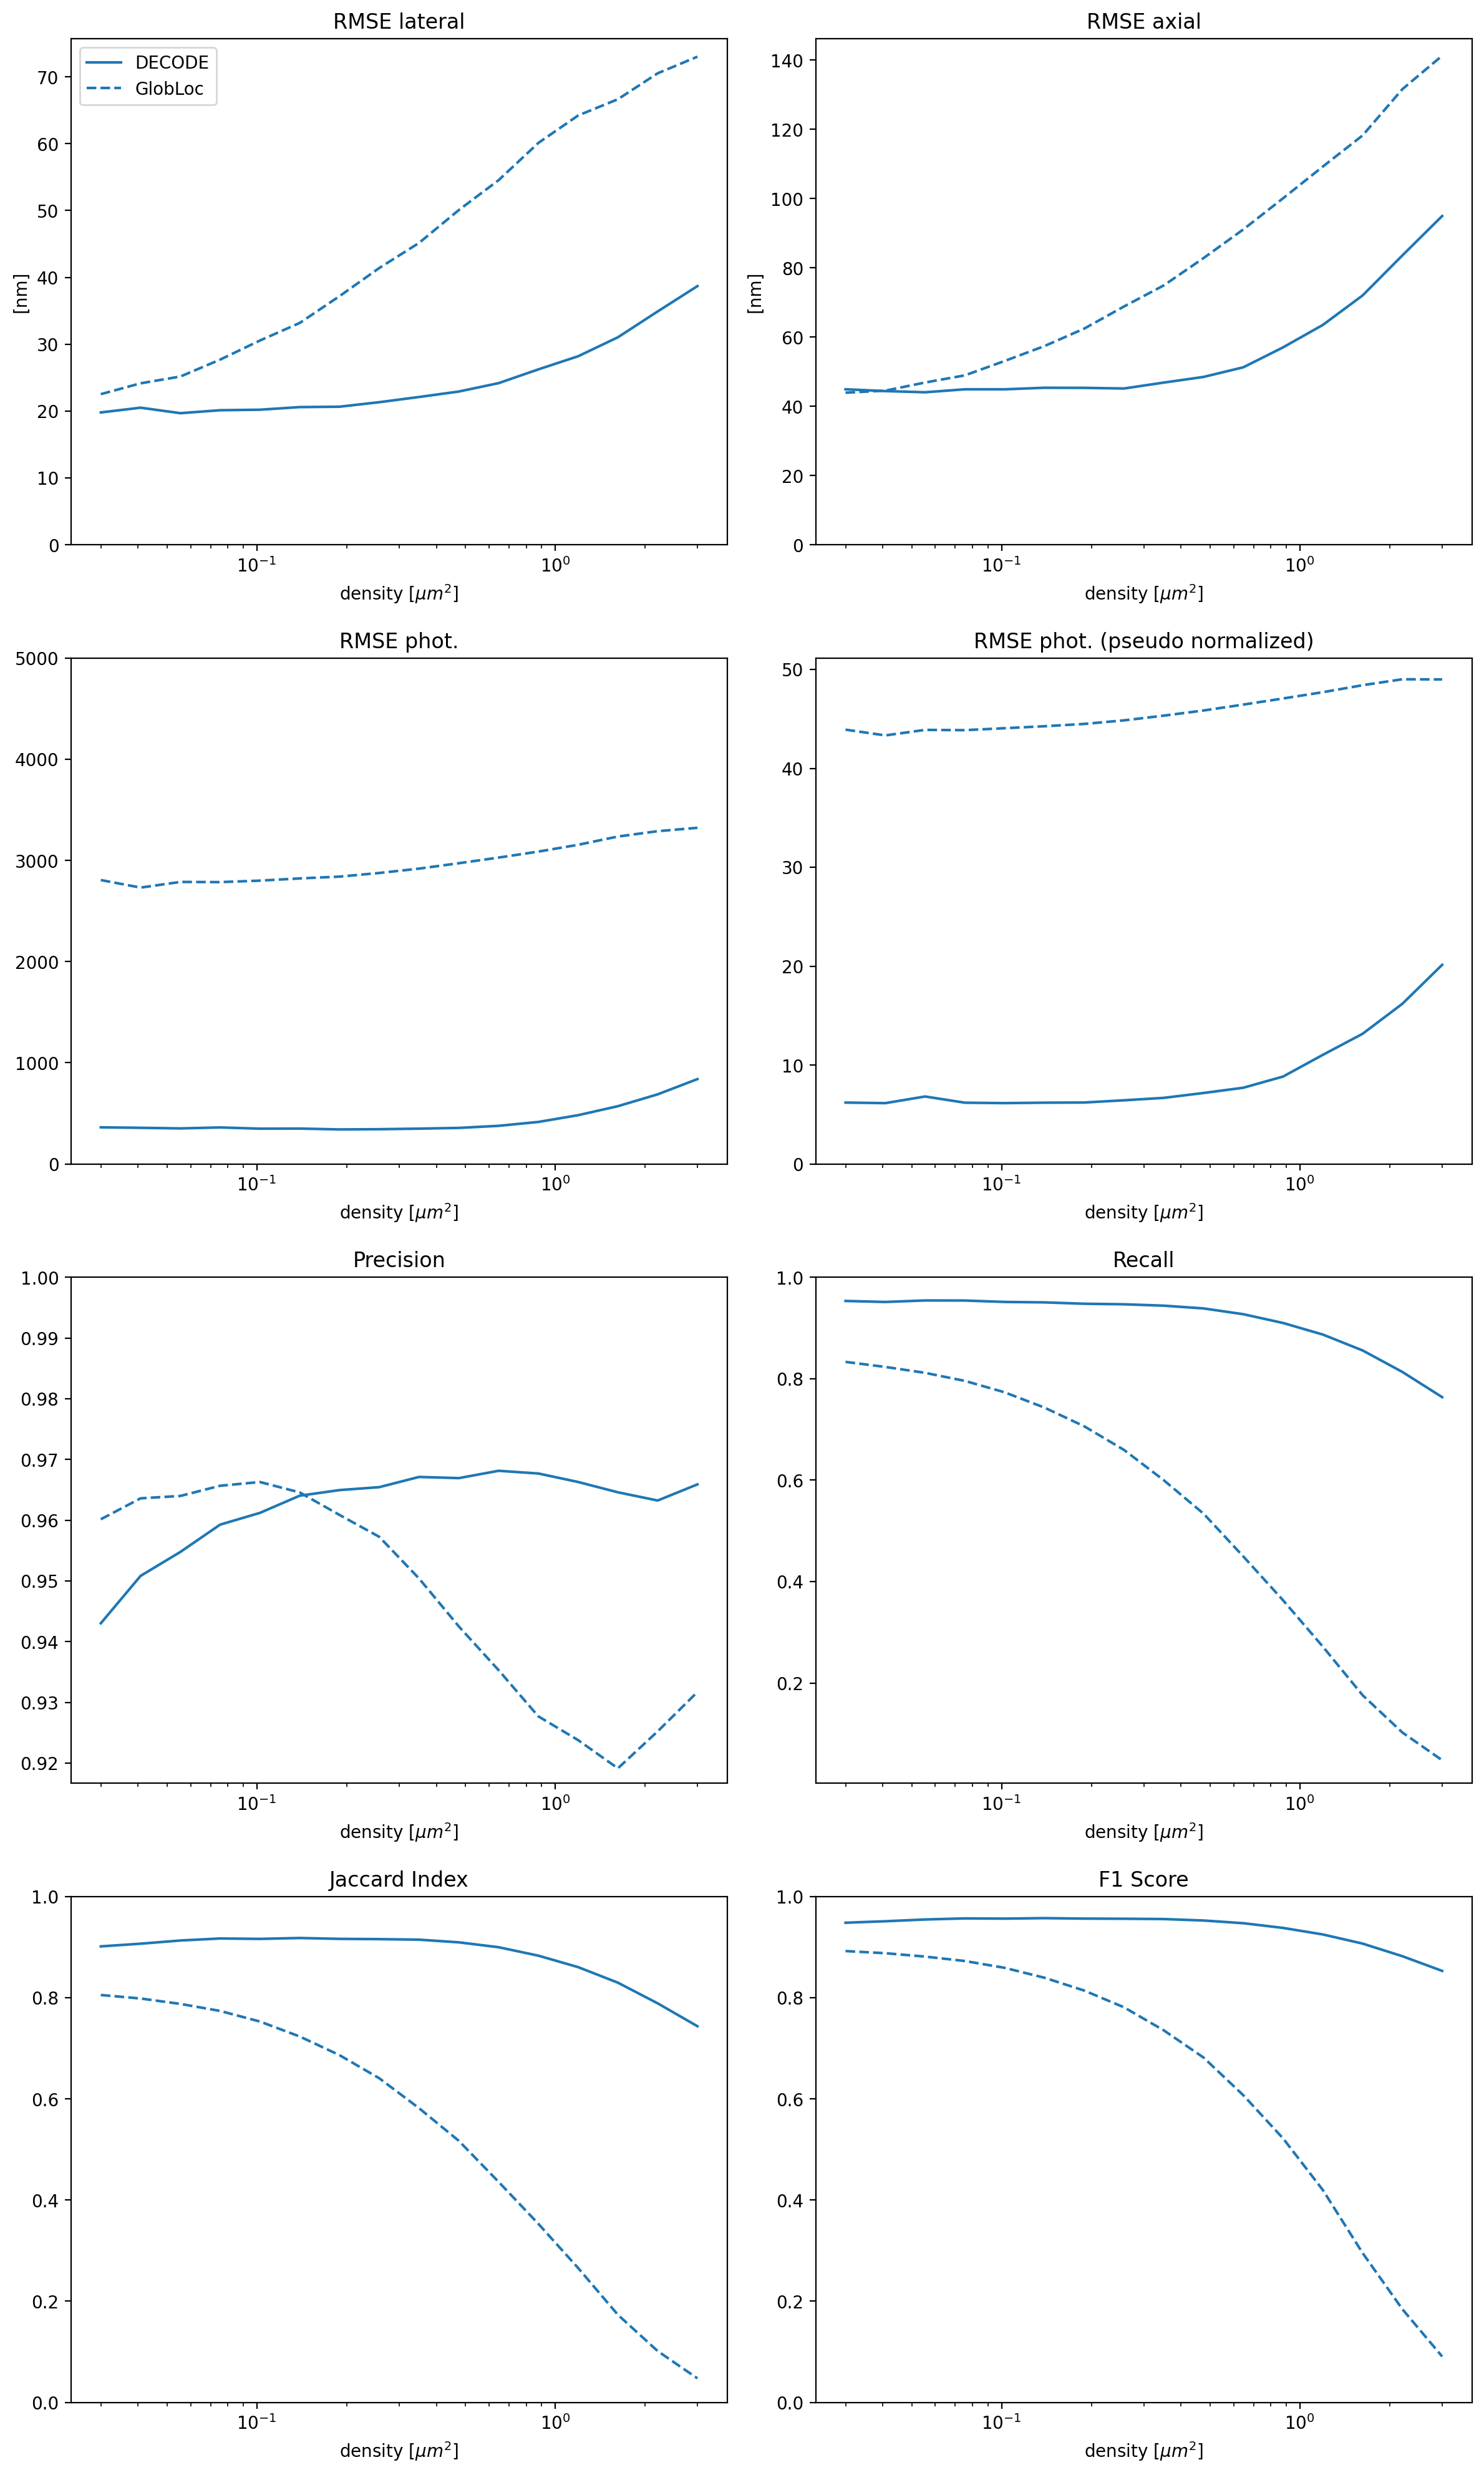

In [15]:
from matplotlib.lines import Line2D
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(12, 20))

prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]
markers = ["-", "--"]

plt_lines = []


metrics = {
    "rmse_lat": {"pretty": "RMSE lateral", "ylabel": "[nm]", "ylim": [0., None], "yscale": "linear"},
    "rmse_ax": {"pretty": "RMSE axial", "ylabel": "[nm]", "ylim": [0., None], "yscale": "linear"},
    "rmse_phot": {"pretty": "RMSE phot.", "ylabel": "", "ylim": [0, 5000], "yscale": "linear"},
    "rmse_phot_pnorm": {"pretty": "RMSE phot. (pseudo normalized)", "ylabel": "", "ylim": [0, None], "yscale": "linear"},
    "prec": {"pretty": "Precision", "ylabel": "", "ylim": [None, 1.], "yscale": "linear"},
    "rec": {"pretty": "Recall", "ylabel": "", "ylim": [None, 1.], "yscale": "linear"},
    "jac": {"pretty": "Jaccard Index", "ylabel": "", "ylim": [0., 1.], "yscale": "linear"},
    "f1": {"pretty": "F1 Score", "ylabel": "", "ylim": [0., 1.], "yscale": "linear"},
    # "acc_code": {"pretty": "Accuracy Color", "ylabel": "", "ylim": [None, 1.], "yscale": "linear"},
    # "rejection": {"pretty": "Rejection Rate", "ylabel": "", "ylim": [0, None], "yscale": "linear"},
}
m_default = {"pretty": None, "ylim": None, "yscale": "linear"}

for i, (metric, ax) in enumerate(zip(metrics, axs.flat, strict=True)):
    if metric not in evals.columns:
        continue

    plt_lines = []
    for snr, color in zip(scen_names_pretty, colors):
        for alg, marker in zip(["DECODE", "SMAP"], markers):
            s = evals.join(scen).xs(snr, level="snr").xs(alg, level="algorithm")
            s = s.reset_index().sort_values("n_emitter")

            l, = ax.plot(s.density, s[metric], label=f"{scen_names_pretty[snr]}", color=color, linestyle=marker)
            plt_lines.append(l)

    if i == 0:
        marker_legend = ax.legend(
            [
                Line2D([0], [0], linestyle="-"),#, color="blue"),
                Line2D([0], [0], linestyle="--"),#, color="blue"),
            ],
            ["DECODE", "GlobLoc"],
            loc="best",
        )

        # line_legend = ax.legend(handles=plt_lines[::2], loc="lower left")
        # ax.add_artist(line_legend)

    m_args = m_default.copy()
    m_args |= metrics[metric]

    ax.set_ylim(m_args["ylim"])
    ax.set_xscale("log")
    ax.set_yscale(m_args["yscale"])

    ax.set_title(m_args["pretty"])
    ax.set_xlabel(r"density [$\mu m^2$]")
    ax.set_ylabel(m_args["ylabel"])

plt.tight_layout()

if path_out is not None:
    plt.savefig(path_out / "metrics.png", dpi=300, bbox_inches="tight")
    plt.savefig(path_out / "metrics.eps",format='eps', dpi=300, bbox_inches="tight")
    # # save individual axs
    # for i, ax in enumerate(axs.flat):
    #     extent = full_extent(ax).transformed(fig.dpi_scale_trans.inverted())
    #     fig.savefig(path_out / f"metrics_ax_{i}.png", dpi=300, bbox_inches=extent)
else:
    plt.show()


In [17]:
# sample frames
df_frames = scen.join(scen_pred[["em_out_fil"]].xs("DECODE", level=2)).iloc[[0, 8, 15]]
f_plot = [frames[i] for i in df_frames.index.get_level_values("index")]

df_frames


n_emitter   density  n_frames  phot_loc  phot_scale  \
snr    index                                                          
medium 0        11.624977  0.030000      1000    5000.0      1250.0   
       8       135.537292  0.349774       737    5000.0      1250.0   
       15     1162.497681  3.000000        86    5000.0      1250.0   

                        bg      choric  lifetime  phot_min  \
snr    index                                                 
medium 0      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       8      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       15     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   

                                                             em  \
snr    index                                                      
medium 0      EmitterSet
::num emitters: 11076
::xy unit: px...   
       8      EmitterSet
::num emitters: 95804
::xy unit: px...   
       15     EmitterSet
::num emitters: 97502
::xy unit: px...   

                                                          em_ch  \
snr    index                                                      
medium 0      EmitterSet
::num emitters: 11076
::xy unit: px...   
       8      EmitterSet
::num emitters: 95804
::xy unit: px...   
       15     EmitterSet
::num emitters: 97502
::xy unit: px...   

                                                     em_out_fil  
snr    index                                                     
medium 0      EmitterSet
::num emitters: 11197
::xy unit: px...  
       8      EmitterSet
::num emitters: 93518
::xy unit: px...  
       15     EmitterSet
::num emitters: 77084
::xy unit: px...

[03-04-2026 22:32:27] [matplotlib.backends.backend_ps] [WARNING] The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


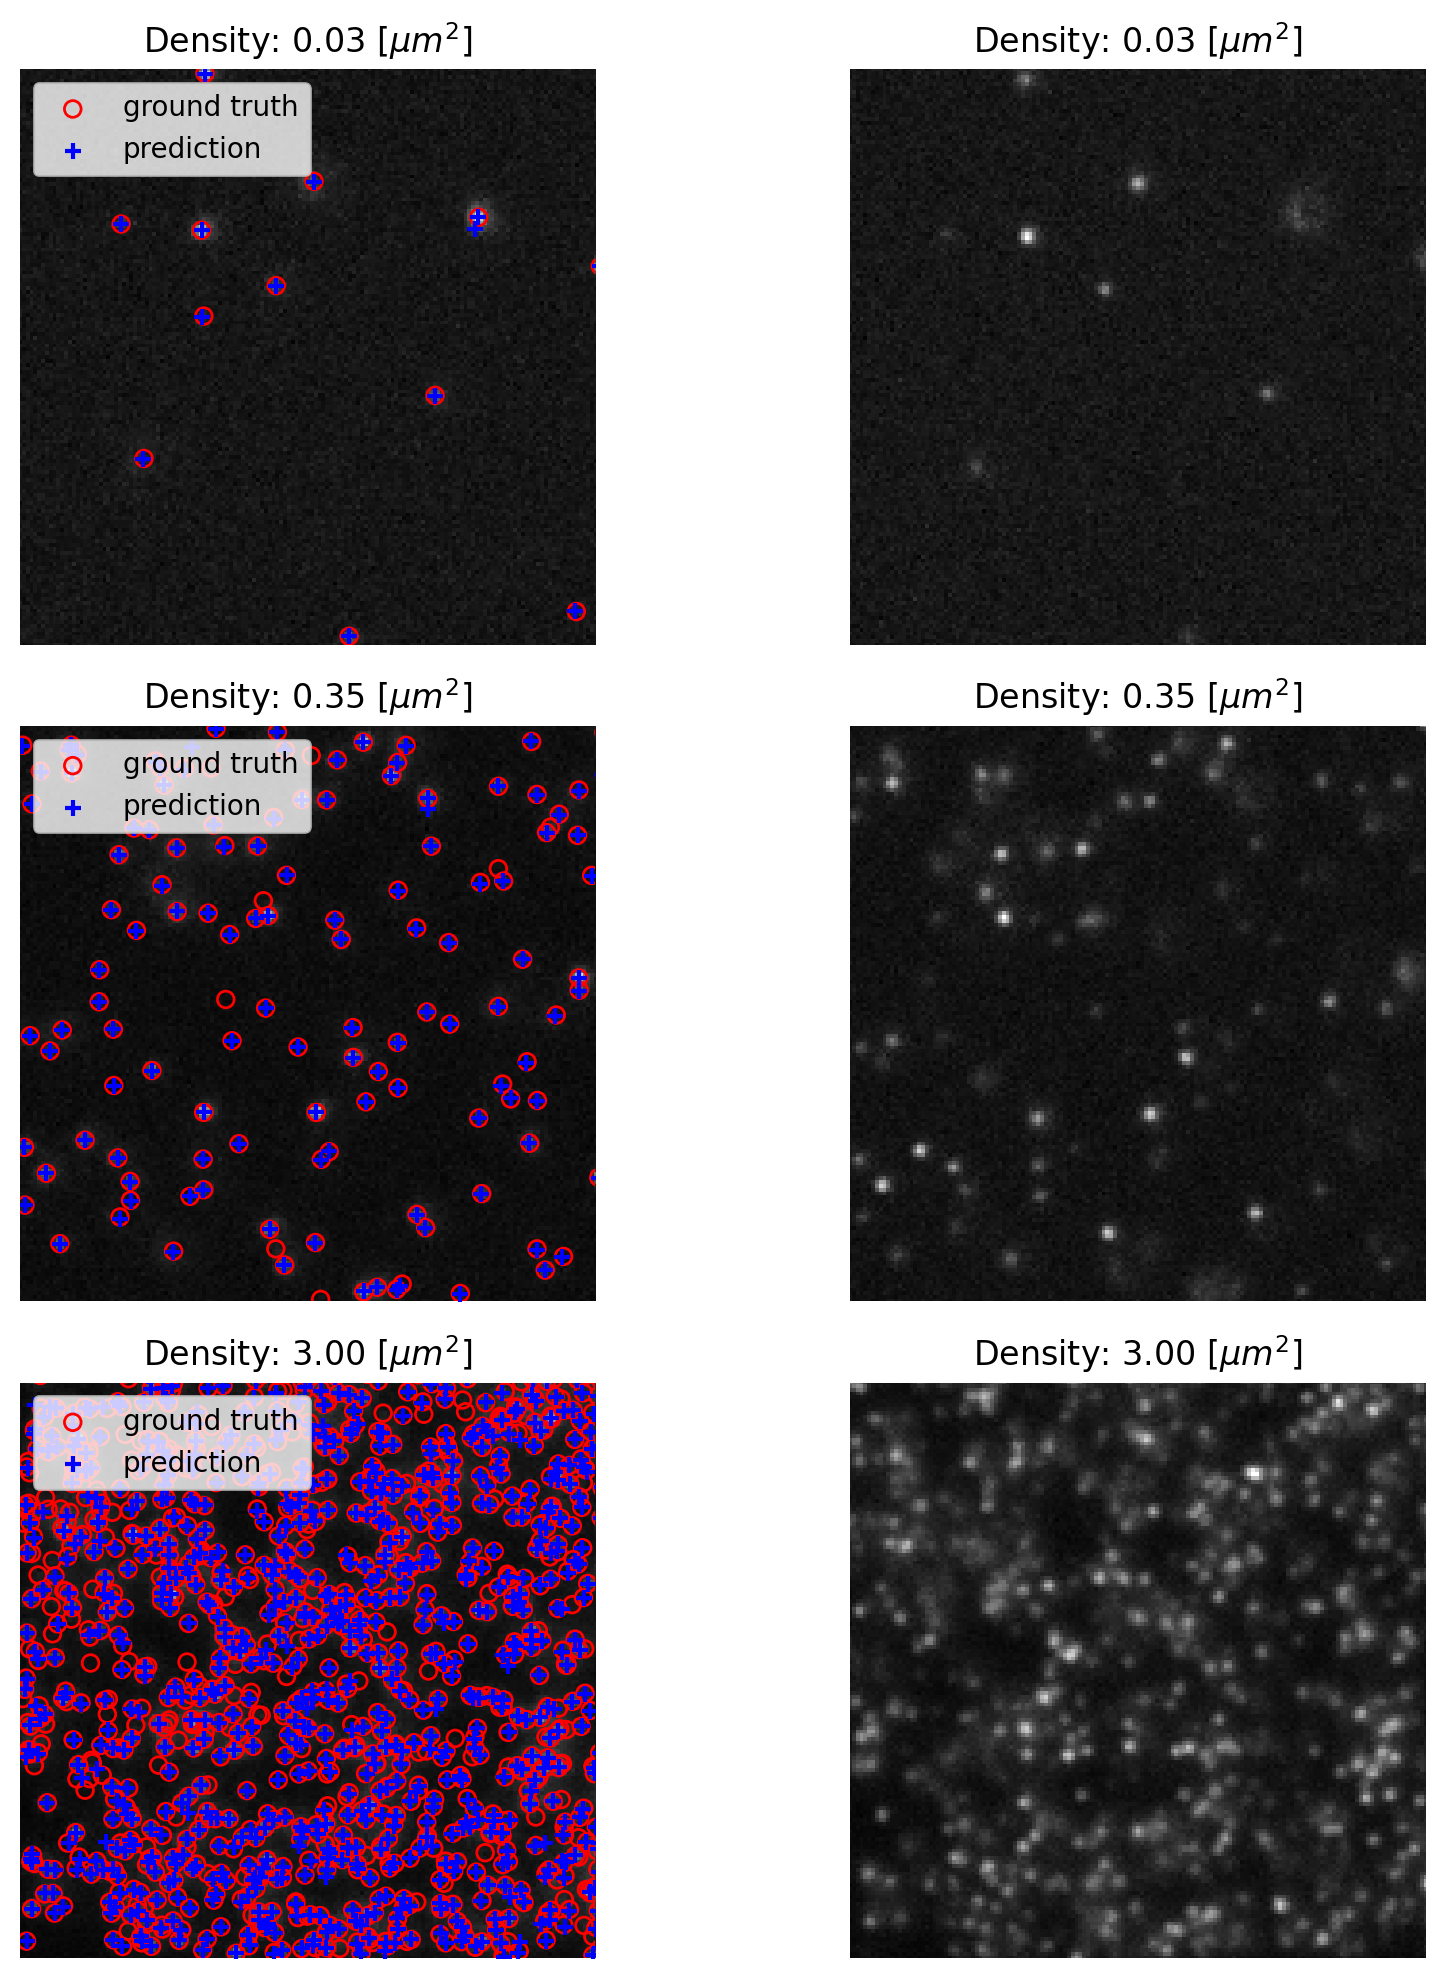

In [20]:
f_ix = 42

xlim = [50, 200]
ylim = xlim

fig, axs = plt.subplots(nrows=len(df_frames), ncols=2, figsize=(10, 10))

for i, ((_, s), f) in enumerate(zip(df_frames.iterrows(), f_plot)):
    em = s.em_ch.iframe[f_ix]
    em_out = s.em_out_fil.iframe[f_ix]

    for j, ff in enumerate(f):
        axs[i, j].imshow(ff[f_ix], cmap="gray")

    axs[i, 0].scatter(em.xyz_px[:, 0, 1], em.xyz_px[:, 0, 0], label="ground truth", marker="o", facecolor="none", edgecolors="r")
    # axs[i, 1].scatter(em.xyz_px[:, 1, 1], em.xyz_px[:, 1, 0], label="channel 2")#, marker="o", facecolor="none", edgecolors="b")

    # decode predictions
    axs[i, 0].scatter(em_out.xyz_px[:, 1], em_out.xyz_px[:, 0], label="prediction", marker="+", facecolor="b", edgecolors="none")
    # axs[i, 1].scatter(em.xyz_px[:, 1, 1], em.xyz_px[:, 1, 0], label="channel 2")#, marker="o", facecolor="none", edgecolors="b")

    for j in range(2):
        ax = axs[i, j]
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_axis_off()
        ax.set_title(f"Density: {s.density:.2f} [$\mu m^2$]")
        # ax.legend(loc="lower right")

        if j == 0:
            ax.legend(loc="upper left", frameon=True)

    plt.tight_layout()

if path_out is not None:
    plt.savefig(path_out / "sample_frames.png", dpi=300, bbox_inches="tight")
    plt.savefig(path_out / "sample_frames.eps",format='eps', dpi=300, bbox_inches="tight")
else:
    plt.show()

# Debugging

In [23]:
scen

n_emitter   density  n_frames  phot_loc  phot_scale  \
snr    index                                                          
medium 0        11.624977  0.030000      1000    5000.0      1250.0   
       1        15.802486  0.040781      1000    5000.0      1250.0   
       2        21.481211  0.055435      1000    5000.0      1250.0   
       3        29.200621  0.075357      1000    5000.0      1250.0   
       4        39.694050  0.102436      1000    5000.0      1250.0   
       5        53.958359  0.139248      1000    5000.0      1250.0   
       6        73.348648  0.189287      1000    5000.0      1250.0   
       7        99.706947  0.257309      1000    5000.0      1250.0   
       8       135.537292  0.349774       737    5000.0      1250.0   
       9       184.243484  0.475468       542    5000.0      1250.0   
       10      250.452545  0.646330       399    5000.0      1250.0   
       11      340.454254  0.878593       293    5000.0      1250.0   
       12      462.798676  1.194322       216    5000.0      1250.0   
       13      629.108337  1.623509       158    5000.0      1250.0   
       14      855.182434  2.206927       116    5000.0      1250.0   
       15     1162.497681  3.000000        86    5000.0      1250.0   

                        bg      choric  lifetime  phot_min  \
snr    index                                                 
medium 0      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       1      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       2      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       3      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       4      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       5      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       6      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       7      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       8      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       9      [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       10     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       11     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       12     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       13     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       14     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   
       15     [50.0, 50.0]  [1.0, 1.0]       1.0     100.0   

                                                             em  \
snr    index                                                      
medium 0      EmitterSet
::num emitters: 11076
::xy unit: px...   
       1      EmitterSet
::num emitters: 15306
::xy unit: px...   
       2      EmitterSet
::num emitters: 20682
::xy unit: px...   
       3      EmitterSet
::num emitters: 28210
::xy unit: px...   
       4      EmitterSet
::num emitters: 38956
::xy unit: px...   
       5      EmitterSet
::num emitters: 52219
::xy unit: px...   
       6      EmitterSet
::num emitters: 71697
::xy unit: px...   
       7      EmitterSet
::num emitters: 96771
::xy unit: px...   
       8      EmitterSet
::num emitters: 95804
::xy unit: px...   
       9      EmitterSet
::num emitters: 96407
::xy unit: px...   
       10     EmitterSet
::num emitters: 97605
::xy unit: px...   
       11     EmitterSet
::num emitters: 96536
::xy unit: px...   
       12     EmitterSet
::num emitters: 96681
::xy unit: px...   
       13     EmitterSet
::num emitters: 96808
::xy unit: px...   
       14     EmitterSet
::num emitters: 96355
::xy unit: px...   
       15     EmitterSet
::num emitters: 97502
::xy unit: px...   

                                                          em_ch  
snr    index                                                     
medium 0      EmitterSet
::num emitters: 11076
::xy unit: px...  
       1      EmitterSet
::num emitters: 15306
::xy unit: px...  
       2      EmitterSet
::num emitters: 20682
::xy unit: px...  
       3      EmitterSet
::num emitters: 28210
::xy unit: px...  
       4      Emi

In [24]:
r = matches.iloc[1]
f = frames[0]
em_out = scen_pred.iloc[0].em_out
tp, fp, fn, tp_match = r["tp"], r["fp"], r["fn"], r["tp_match"]

# _ = plt.hist(fn.phot, bins=100, alpha=0.5, label="fn")

(100.0, 30000.0)

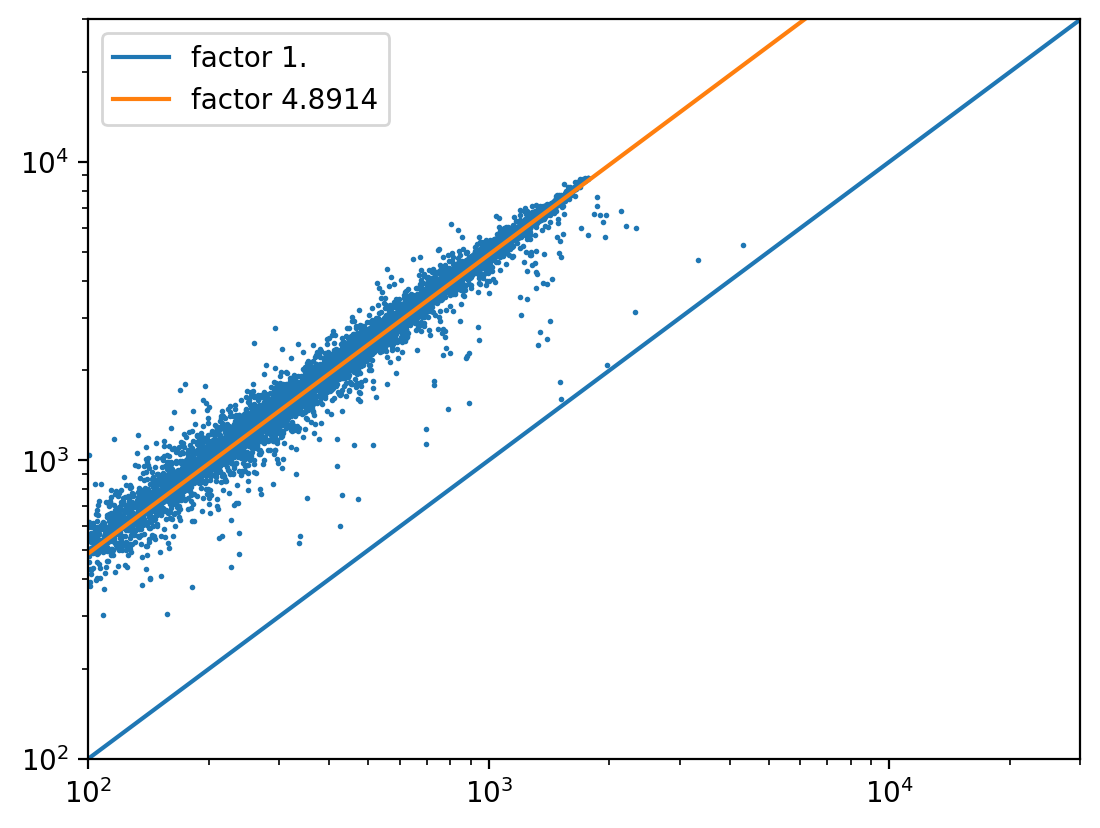

In [25]:
plt.scatter(tp.phot[:], tp_match.phot[:], s=1)
x = torch.linspace(0, 1e6, 100)
plt.plot(x, x, label="factor 1.")
plt.plot(x, x*4.8914, label="factor 4.8914")

plt.legend()
plt.xscale("log")
plt.yscale("log")

plt.xlim(1e2, 3e4)
plt.ylim(1e2, 3e4)

In [26]:
d = (tp.xyz_nm - tp_match.xyz_nm)
d.median(0)

torch.return_types.median(
values=tensor([ 8.3901,  1.3672, -8.6068]),
indices=tensor([8100, 4052, 2803]))

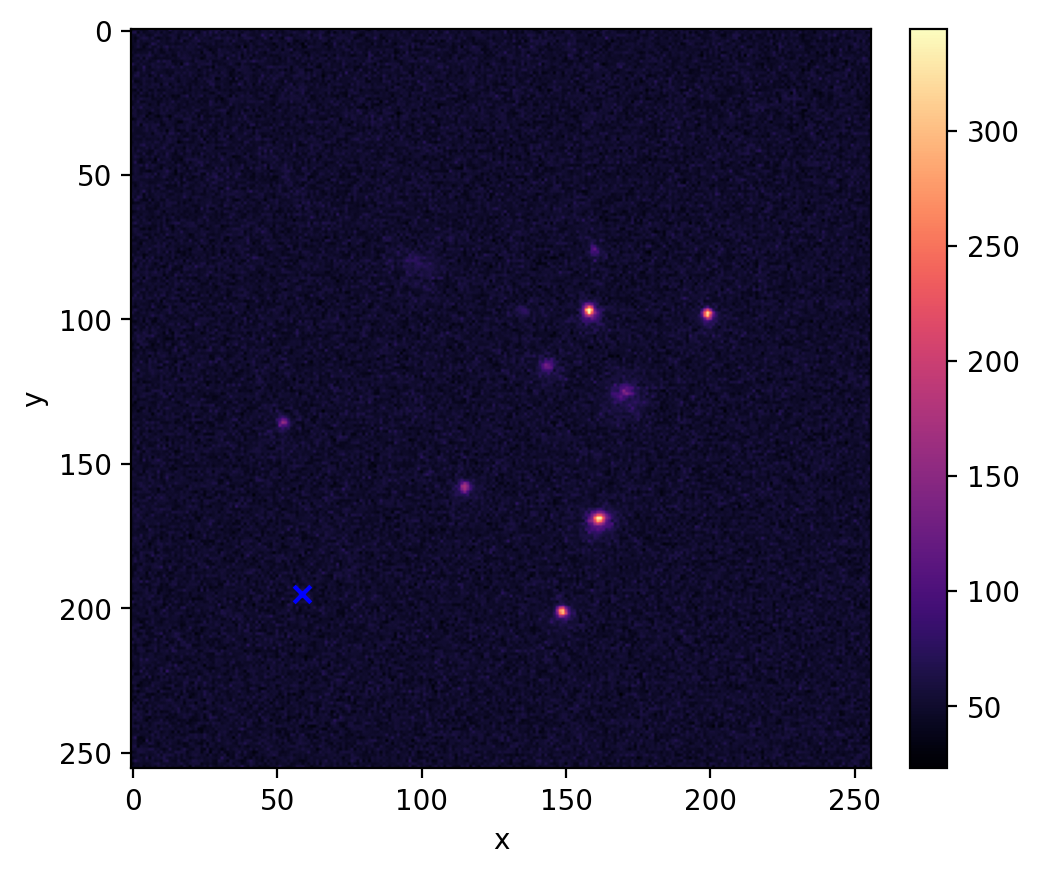

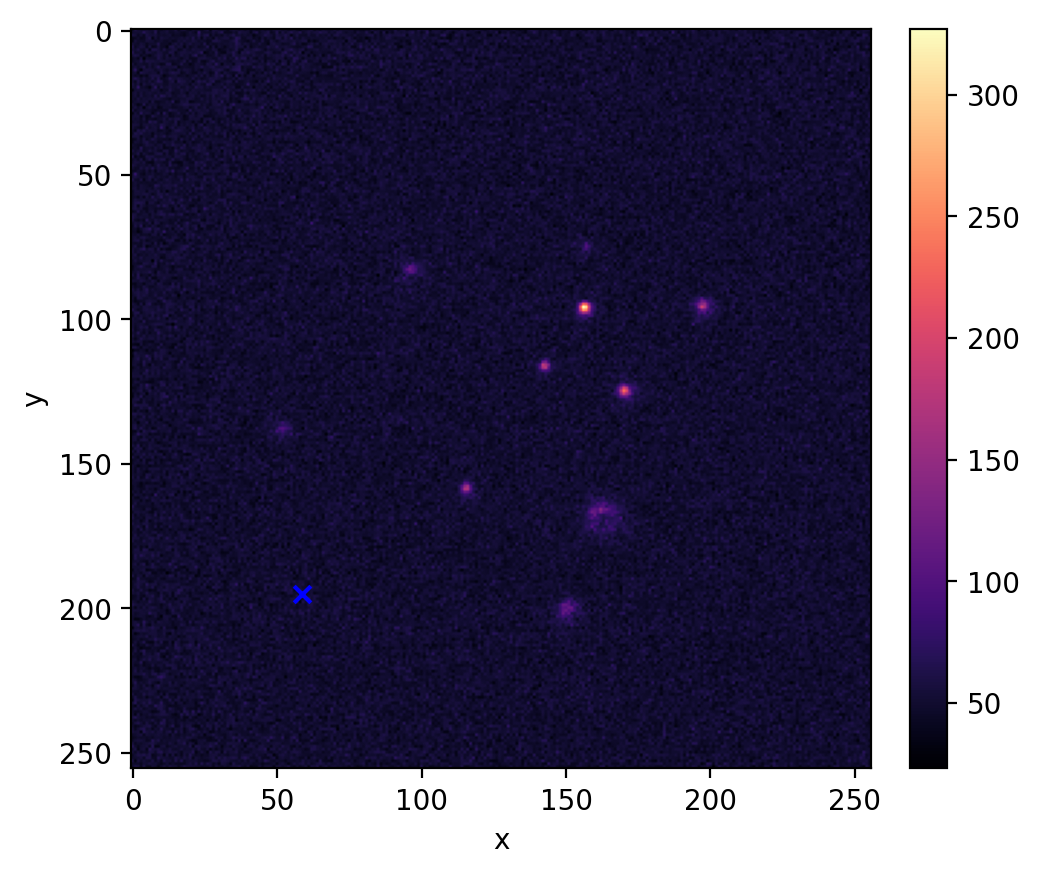

In [27]:
f_ix = 42

decode.plot.PlotFrameCoord(f[0][f_ix], pos_out=fn.iframe[f_ix].xyz_px).plot()
plt.show()
decode.plot.PlotFrameCoord(f[1][f_ix], pos_out=fn.iframe[f_ix].xyz_px).plot()
plt.show()

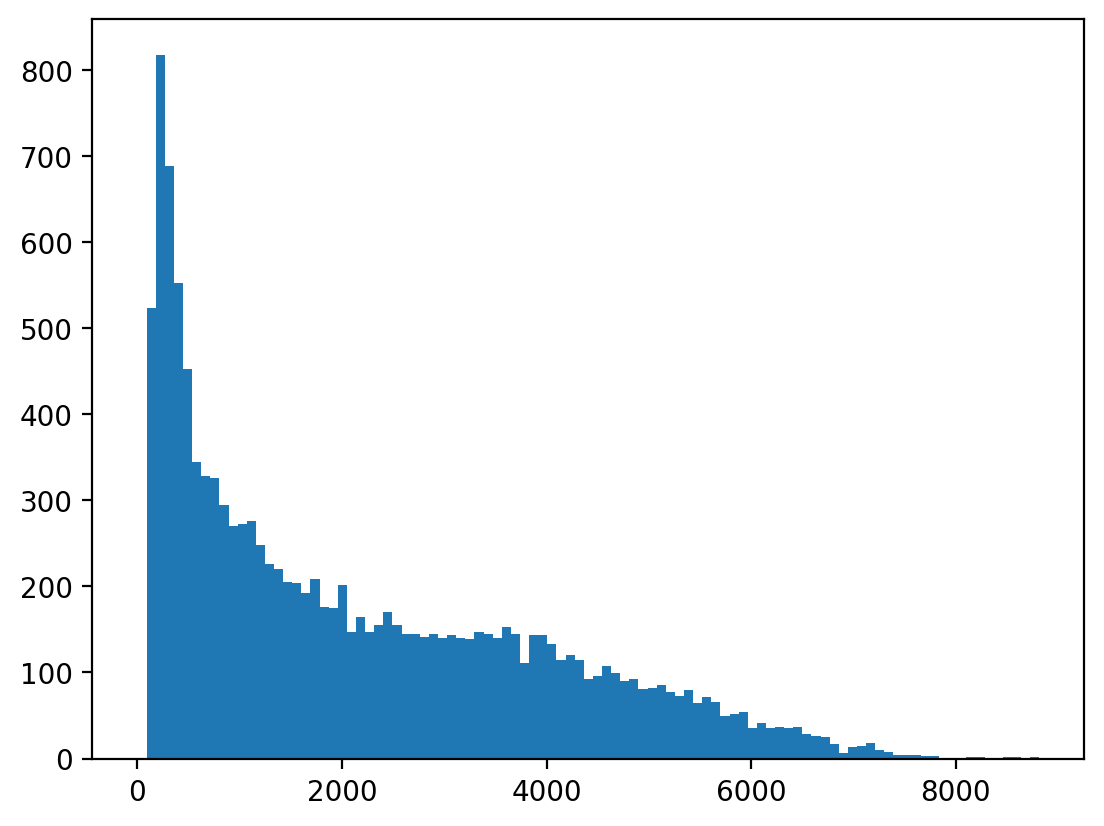

In [28]:
_ = plt.hist(em_out.phot, bins=torch.linspace(0, em_out.phot.max(), 100))
# _ = plt.hist(em_out.phot[:, 1] / em_out.phot.sum(1), bins=100)

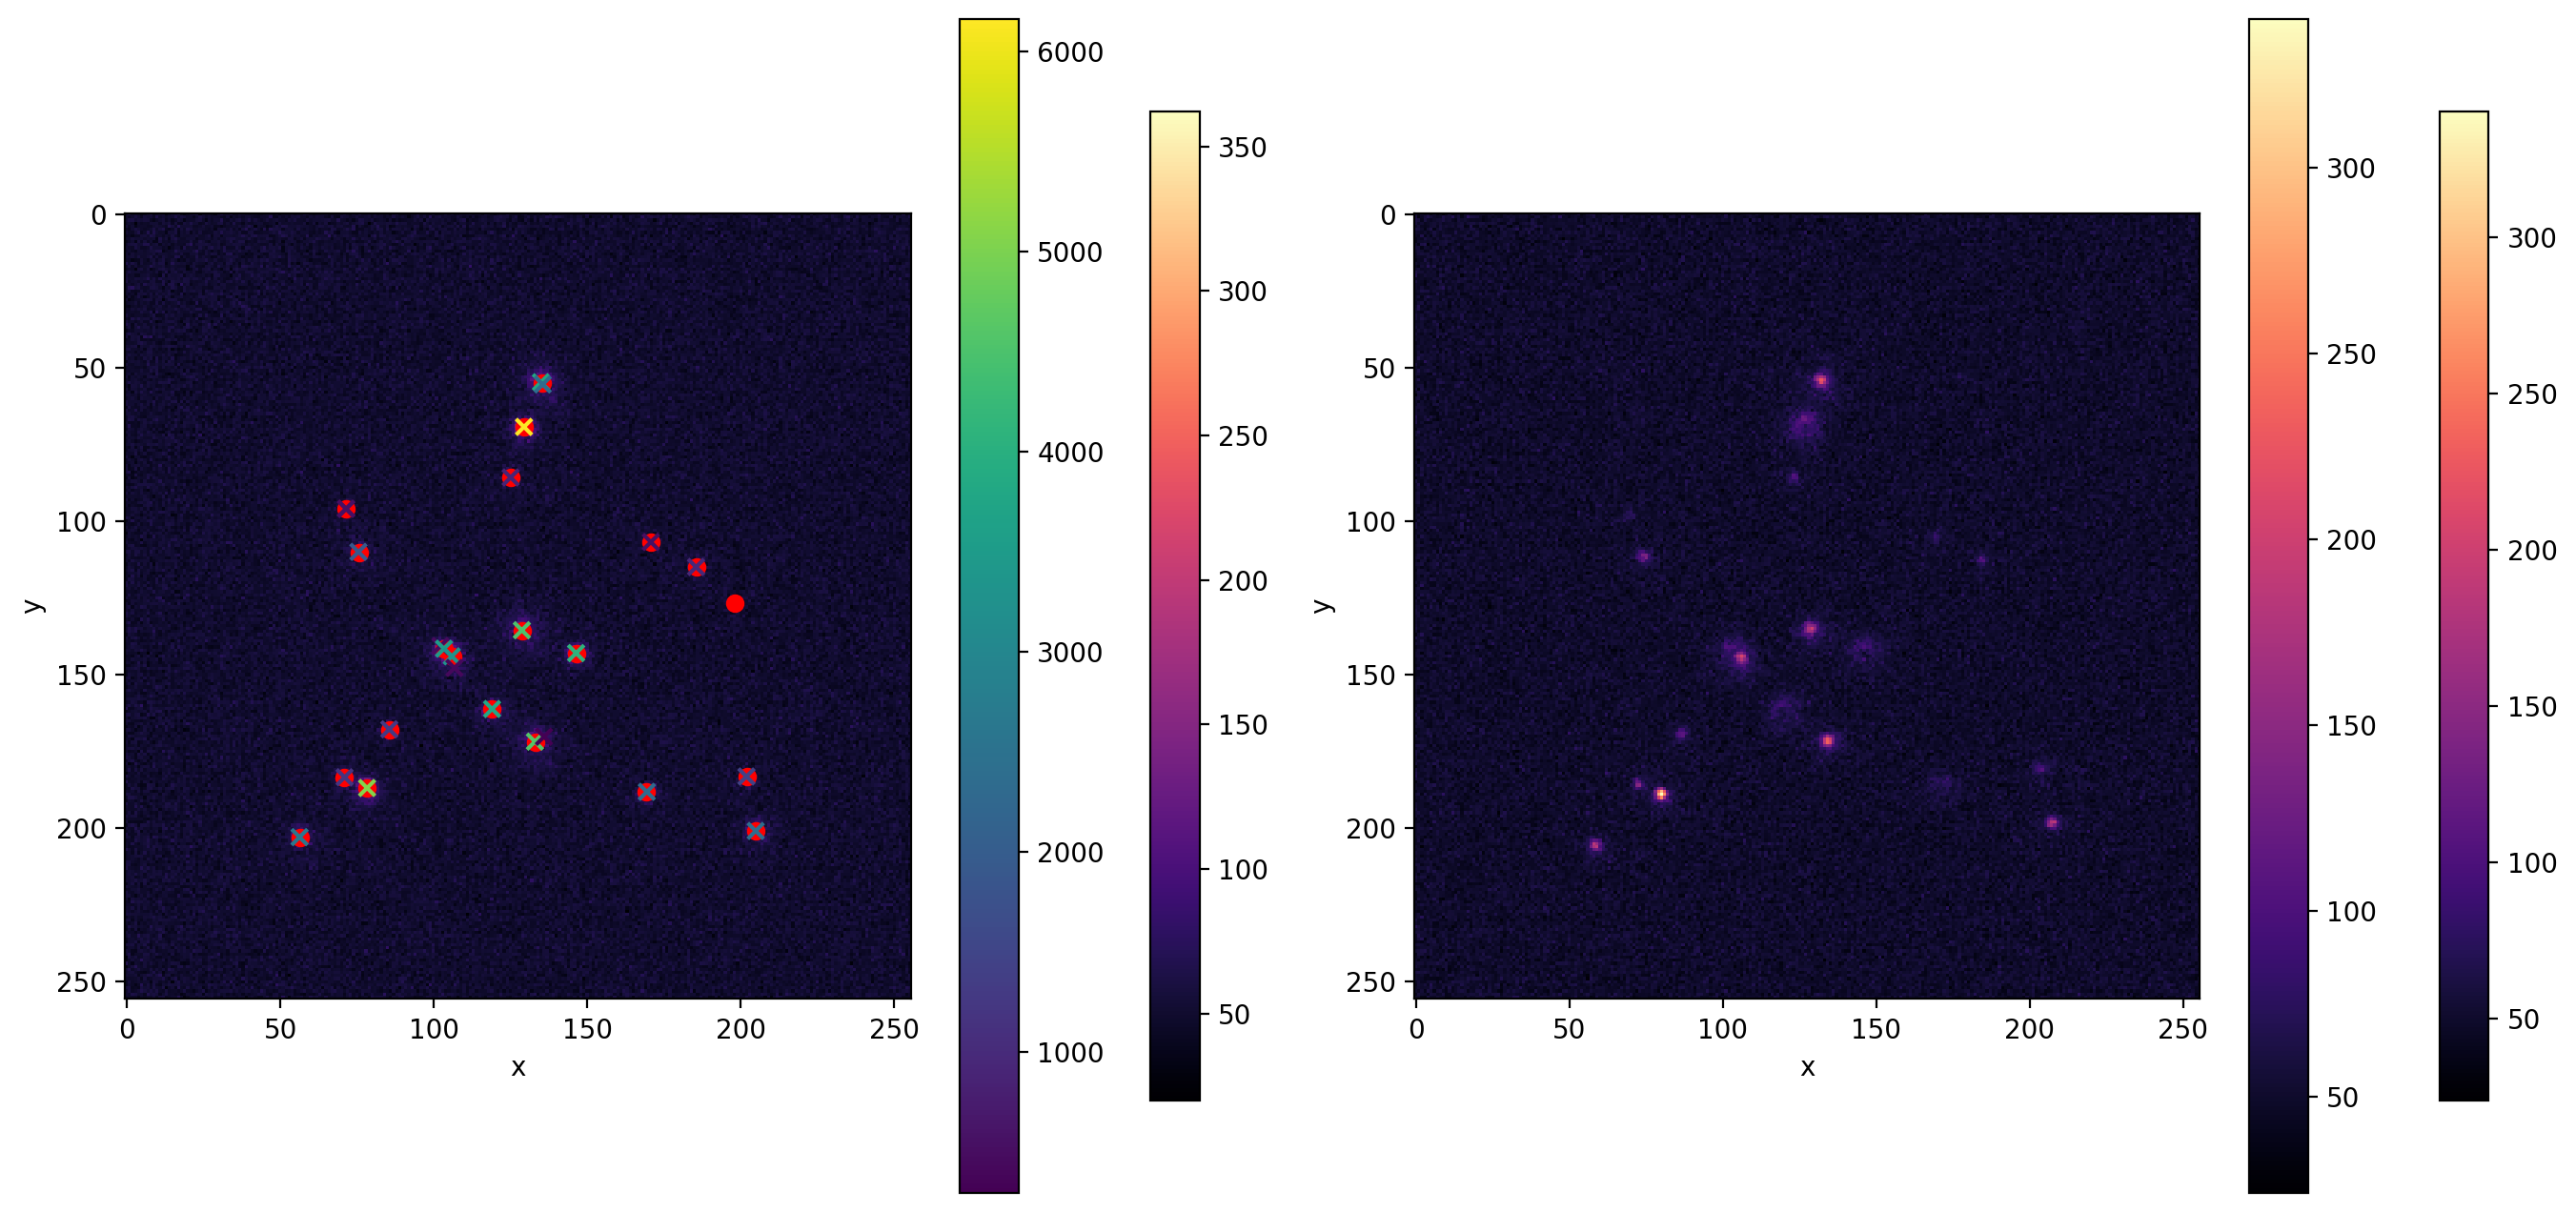

In [29]:
# check on some frames
ix_scen = 2  # linear index
ix_frame = 19

fplot = frames[ix_scen]
em_out = scen_decode.xs(ix_scen, level="index")["em_out"][0]
em_gt = scen.xs(ix_scen, level="index")["em"][0]

f, ax = plt.subplots(1, 2, figsize=(16, 8))
plt.sca(ax[0])
decode.plot.PlotFrameCoord(
    fplot[0][ix_frame],
    pos_tar=em_gt.iframe[ix_frame].xyz_px,
    pos_out=em_out.iframe[ix_frame].xyz_px,
    phot_out=em_out.iframe[ix_frame].phot,
    # pos_tar=em_gt.iframe[ix_frame].xyz_px,
).plot()
plt.colorbar()

plt.sca(ax[1])
decode.plot.PlotFrameCoord(
   fplot[1][ix_frame],
    # pos_out=em_x.iframe[f_ix].xyz_px[:, 1]
).plot()
plt.colorbar()